<a href="https://colab.research.google.com/github/harshadbabar26-dev/HB1/blob/main/prophet_file.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


========== Forecast (2027-2030) ==========

    Year  Predicted_Migration    Lower_Bound   Upper_Bound
36  2027         8.800680e+05  856209.123165  9.050260e+05
37  2028         9.273998e+05  903179.265747  9.525341e+05
38  2029         9.785757e+05  949676.624202  1.005829e+06
39  2030         1.033368e+06  999924.872127  1.064847e+06


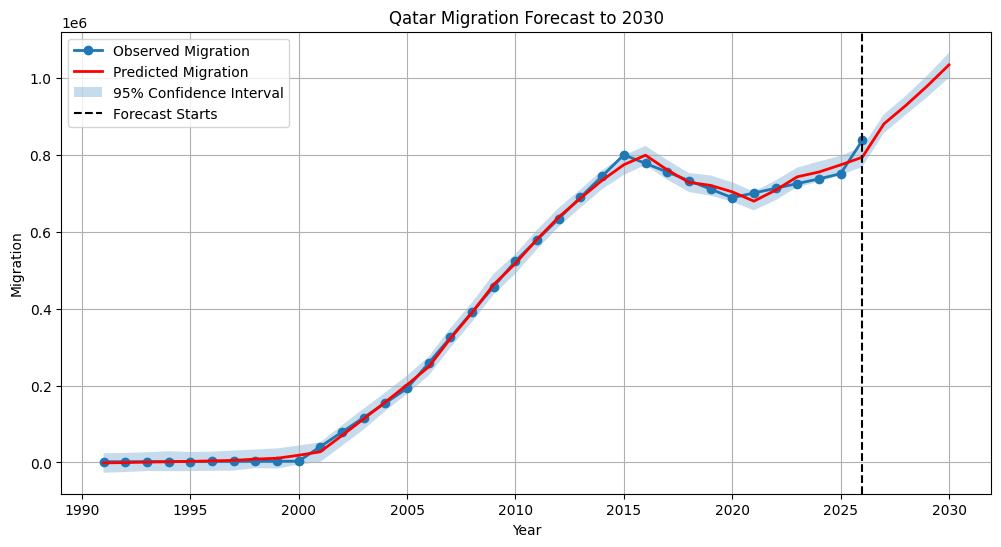

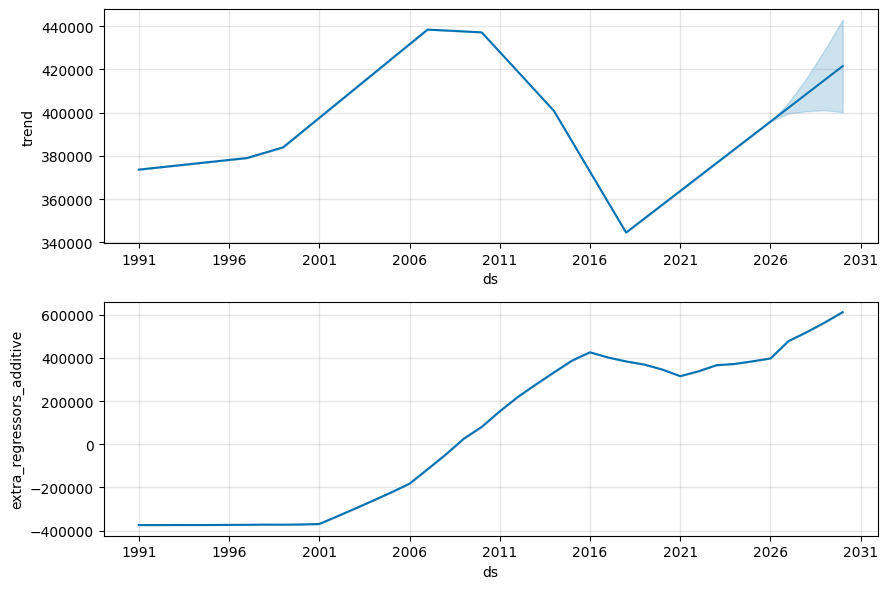


========== MODEL PERFORMANCE ==========

Country : Qatar
Mean Migration : 392,662.44
RMSE : 12,980.65
MAE  : 9,257.61
RMSE Percentage : 3.31%
MAE Percentage  : 2.36%
MAPE : 41.19%
Forecast Accuracy : 58.81%


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

# =====================================================
# LOAD DATA
# =====================================================

df = pd.read_excel("/content/Final_Master_Dataset_Cleaned (3).xlsx")

# =====================================================
# SELECT COUNTRY
# =====================================================

# country = "Saudi Arabia"
country = "Qatar"
# country = "United Arab Emirates"

df = df[df["Country"] == country].copy()
df = df.sort_values("Year").reset_index(drop=True)

# =====================================================
# CREATE LAG VARIABLES
# =====================================================

df["GDP_Lag1"] = df["GDP"].shift(1)
df["Migration_Lag1"] = df["Migration"].shift(1)

df = df.dropna().reset_index(drop=True)

# =====================================================
# PREPARE DATA
# =====================================================

prophet_df = df[
    ["Year","Migration","GDP_Lag1","Migration_Lag1"]
].copy()

prophet_df.columns = [
    "ds",
    "y",
    "GDP_Lag1",
    "Migration_Lag1"
]

prophet_df["ds"] = pd.to_datetime(
    prophet_df["ds"].astype(str) + "-01-01"
)

# =====================================================
# BUILD MODEL
# =====================================================

model = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.2,
    interval_width=0.95
)

model.add_regressor("GDP_Lag1")
model.add_regressor("Migration_Lag1")

model.fit(prophet_df)

# =====================================================
# CREATE FUTURE DATA
# =====================================================

future = model.make_future_dataframe(
    periods=4,
    freq="YS"
)

future["GDP_Lag1"] = np.nan
future["Migration_Lag1"] = np.nan

# Historical values
future.loc[:len(prophet_df)-1,"GDP_Lag1"] = prophet_df["GDP_Lag1"].values
future.loc[:len(prophet_df)-1,"Migration_Lag1"] = prophet_df["Migration_Lag1"].values

# Last available values
last_gdp = df["GDP"].iloc[-1]
last_migration = df["Migration"].iloc[-1]

# =====================================================
# RECURSIVE FORECAST
# =====================================================

for i in range(len(prophet_df), len(future)):

    future.loc[i,"GDP_Lag1"] = last_gdp
    future.loc[i,"Migration_Lag1"] = last_migration

    temp = future.iloc[[i]]

    pred = model.predict(temp)

    last_migration = pred["yhat"].values[0]

# =====================================================
# FINAL FORECAST
# =====================================================

forecast = model.predict(future)

# =====================================================
# FORECAST TABLE
# =====================================================

forecast_table = forecast[
    ["ds","yhat","yhat_lower","yhat_upper"]
].copy()

forecast_table["Year"] = forecast_table["ds"].dt.year

forecast_table = forecast_table[
    forecast_table["Year"] >= 2027
]

forecast_table = forecast_table[
    ["Year","yhat","yhat_lower","yhat_upper"]
]

forecast_table.columns = [
    "Year",
    "Predicted_Migration",
    "Lower_Bound",
    "Upper_Bound"
]

print("\n========== Forecast (2027-2030) ==========\n")
print(forecast_table)

# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(12,6))

plt.plot(
    df["Year"],
    df["Migration"],
    marker="o",
    linewidth=2,
    label="Observed Migration"
)

plt.plot(
    forecast["ds"].dt.year,
    forecast["yhat"],
    color="red",
    linewidth=2,
    label="Predicted Migration"
)

plt.fill_between(
    forecast["ds"].dt.year,
    forecast["yhat_lower"],
    forecast["yhat_upper"],
    alpha=0.25,
    label="95% Confidence Interval"
)

plt.axvline(
    x=df["Year"].max(),
    linestyle="--",
    color="black",
    label="Forecast Starts"
)

plt.title(country + " Migration Forecast to 2030")
plt.xlabel("Year")
plt.ylabel("Migration")
plt.grid(True)
plt.legend()
plt.show()

# =====================================================
# COMPONENTS
# =====================================================

fig2 = model.plot_components(forecast)
plt.show()

# =====================================================
# MODEL EVALUATION
# =====================================================

prediction = forecast.iloc[:len(prophet_df)]

actual = prophet_df["y"].values
predicted = prediction["yhat"].values

rmse = np.sqrt(mean_squared_error(actual, predicted))
mae = mean_absolute_error(actual, predicted)

mean_migration = actual.mean()

rmse_percent = (rmse / mean_migration) * 100
mae_percent = (mae / mean_migration) * 100

mask = actual != 0

mape = np.mean(
    np.abs((actual[mask]-predicted[mask])/actual[mask])
) * 100

accuracy = 100 - mape

# =====================================================
# RESULTS
# =====================================================

print("\n========== MODEL PERFORMANCE ==========\n")

print(f"Country : {country}")

print(f"Mean Migration : {mean_migration:,.2f}")

print(f"RMSE : {rmse:,.2f}")
print(f"MAE  : {mae:,.2f}")

print(f"RMSE Percentage : {rmse_percent:.2f}%")
print(f"MAE Percentage  : {mae_percent:.2f}%")

print(f"MAPE : {mape:.2f}%")
print(f"Forecast Accuracy : {accuracy:.2f}%")


========== Forecast (2027-2030) ==========

    Year  Predicted_Migration   Lower_Bound   Upper_Bound
36  2027         2.217760e+06  2.177198e+06  2.258787e+06
37  2028         2.277381e+06  2.237595e+06  2.318801e+06
38  2029         2.336176e+06  2.290055e+06  2.380825e+06
39  2030         2.394261e+06  2.347418e+06  2.445162e+06


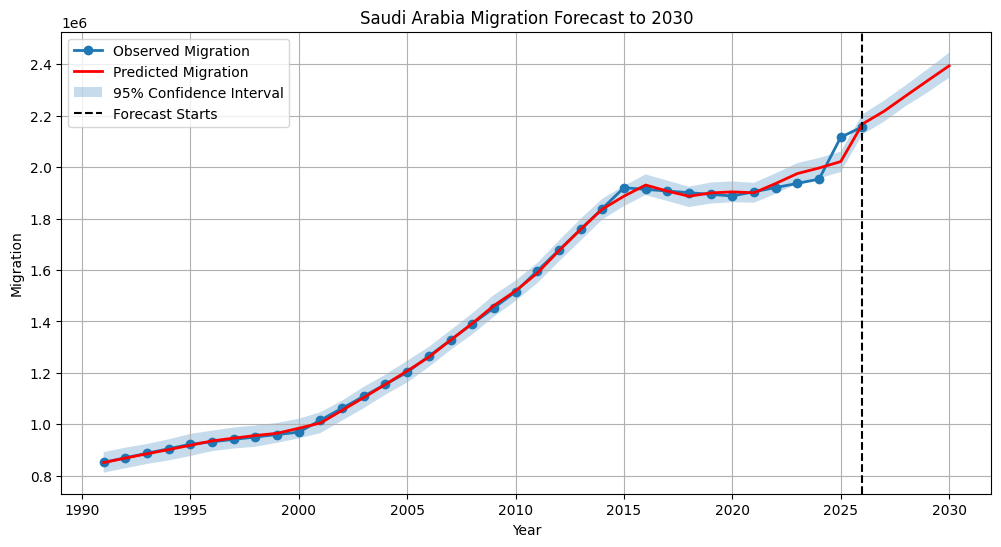

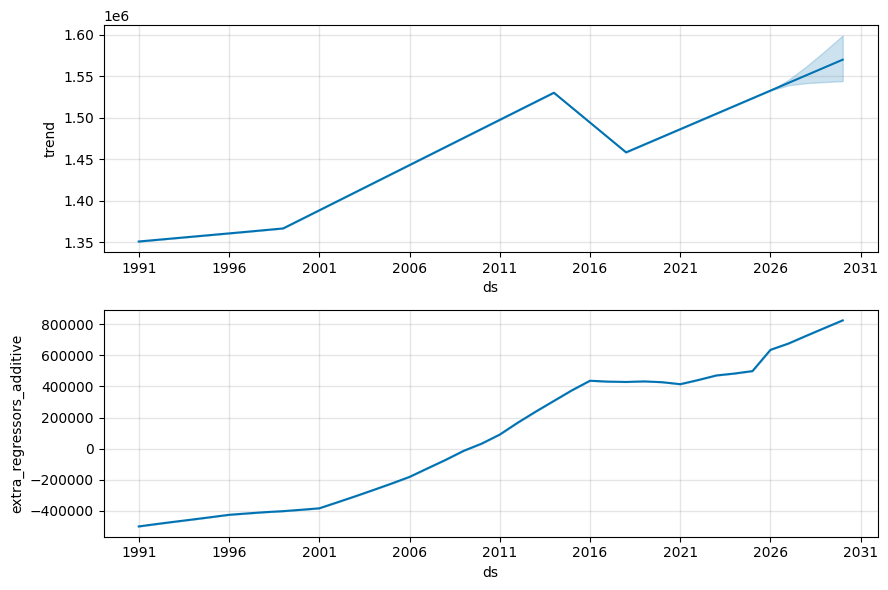


========== MODEL PERFORMANCE ==========

Country : Saudi Arabia
Mean Migration : 1,443,782.58
RMSE : 20,622.41
MAE  : 11,106.73
RMSE Percentage : 1.43%
MAE Percentage  : 0.77%
MAPE : 0.68%
Forecast Accuracy : 99.32%


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

# =====================================================
# LOAD DATA
# =====================================================

df = pd.read_excel("/content/Final_Master_Dataset_Cleaned (3).xlsx")

# =====================================================
# SELECT COUNTRY
# =====================================================

# country = "Saudi Arabia"
country = "Saudi Arabia"
# country = "United Arab Emirates"

df = df[df["Country"] == country].copy()
df = df.sort_values("Year").reset_index(drop=True)

# =====================================================
# CREATE LAG VARIABLES
# =====================================================

df["GDP_Lag1"] = df["GDP"].shift(1)
df["Migration_Lag1"] = df["Migration"].shift(1)

df = df.dropna().reset_index(drop=True)

# =====================================================
# PREPARE DATA
# =====================================================

prophet_df = df[
    ["Year","Migration","GDP_Lag1","Migration_Lag1"]
].copy()

prophet_df.columns = [
    "ds",
    "y",
    "GDP_Lag1",
    "Migration_Lag1"
]

prophet_df["ds"] = pd.to_datetime(
    prophet_df["ds"].astype(str) + "-01-01"
)

# =====================================================
# BUILD MODEL
# =====================================================

model = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.2,
    interval_width=0.95
)

model.add_regressor("GDP_Lag1")
model.add_regressor("Migration_Lag1")

model.fit(prophet_df)

# =====================================================
# CREATE FUTURE DATA
# =====================================================

future = model.make_future_dataframe(
    periods=4,
    freq="YS"
)

future["GDP_Lag1"] = np.nan
future["Migration_Lag1"] = np.nan

# Historical values
future.loc[:len(prophet_df)-1,"GDP_Lag1"] = prophet_df["GDP_Lag1"].values
future.loc[:len(prophet_df)-1,"Migration_Lag1"] = prophet_df["Migration_Lag1"].values

# Last available values
last_gdp = df["GDP"].iloc[-1]
last_migration = df["Migration"].iloc[-1]

# =====================================================
# RECURSIVE FORECAST
# =====================================================

for i in range(len(prophet_df), len(future)):

    future.loc[i,"GDP_Lag1"] = last_gdp
    future.loc[i,"Migration_Lag1"] = last_migration

    temp = future.iloc[[i]]

    pred = model.predict(temp)

    last_migration = pred["yhat"].values[0]

# =====================================================
# FINAL FORECAST
# =====================================================

forecast = model.predict(future)

# =====================================================
# FORECAST TABLE
# =====================================================

forecast_table = forecast[
    ["ds","yhat","yhat_lower","yhat_upper"]
].copy()

forecast_table["Year"] = forecast_table["ds"].dt.year

forecast_table = forecast_table[
    forecast_table["Year"] >= 2027
]

forecast_table = forecast_table[
    ["Year","yhat","yhat_lower","yhat_upper"]
]

forecast_table.columns = [
    "Year",
    "Predicted_Migration",
    "Lower_Bound",
    "Upper_Bound"
]

print("\n========== Forecast (2027-2030) ==========\n")
print(forecast_table)

# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(12,6))

plt.plot(
    df["Year"],
    df["Migration"],
    marker="o",
    linewidth=2,
    label="Observed Migration"
)

plt.plot(
    forecast["ds"].dt.year,
    forecast["yhat"],
    color="red",
    linewidth=2,
    label="Predicted Migration"
)

plt.fill_between(
    forecast["ds"].dt.year,
    forecast["yhat_lower"],
    forecast["yhat_upper"],
    alpha=0.25,
    label="95% Confidence Interval"
)

plt.axvline(
    x=df["Year"].max(),
    linestyle="--",
    color="black",
    label="Forecast Starts"
)

plt.title(country + " Migration Forecast to 2030")
plt.xlabel("Year")
plt.ylabel("Migration")
plt.grid(True)
plt.legend()
plt.show()

# =====================================================
# COMPONENTS
# =====================================================

fig2 = model.plot_components(forecast)
plt.show()

# =====================================================
# MODEL EVALUATION
# =====================================================

prediction = forecast.iloc[:len(prophet_df)]

actual = prophet_df["y"].values
predicted = prediction["yhat"].values

rmse = np.sqrt(mean_squared_error(actual, predicted))
mae = mean_absolute_error(actual, predicted)

mean_migration = actual.mean()

rmse_percent = (rmse / mean_migration) * 100
mae_percent = (mae / mean_migration) * 100

mask = actual != 0

mape = np.mean(
    np.abs((actual[mask]-predicted[mask])/actual[mask])
) * 100

accuracy = 100 - mape

# =====================================================
# RESULTS
# =====================================================

print("\n========== MODEL PERFORMANCE ==========\n")

print(f"Country : {country}")

print(f"Mean Migration : {mean_migration:,.2f}")

print(f"RMSE : {rmse:,.2f}")
print(f"MAE  : {mae:,.2f}")

print(f"RMSE Percentage : {rmse_percent:.2f}%")
print(f"MAE Percentage  : {mae_percent:.2f}%")

print(f"MAPE : {mape:.2f}%")
print(f"Forecast Accuracy : {accuracy:.2f}%")


========== Forecast (2027-2030) ==========

    Year  Predicted_Migration   Lower_Bound   Upper_Bound
36  2027         3.610909e+06  3.584128e+06  3.637796e+06
37  2028         3.723048e+06  3.676796e+06  3.766724e+06
38  2029         3.834514e+06  3.751126e+06  3.919505e+06
39  2030         3.945436e+06  3.829146e+06  4.062699e+06


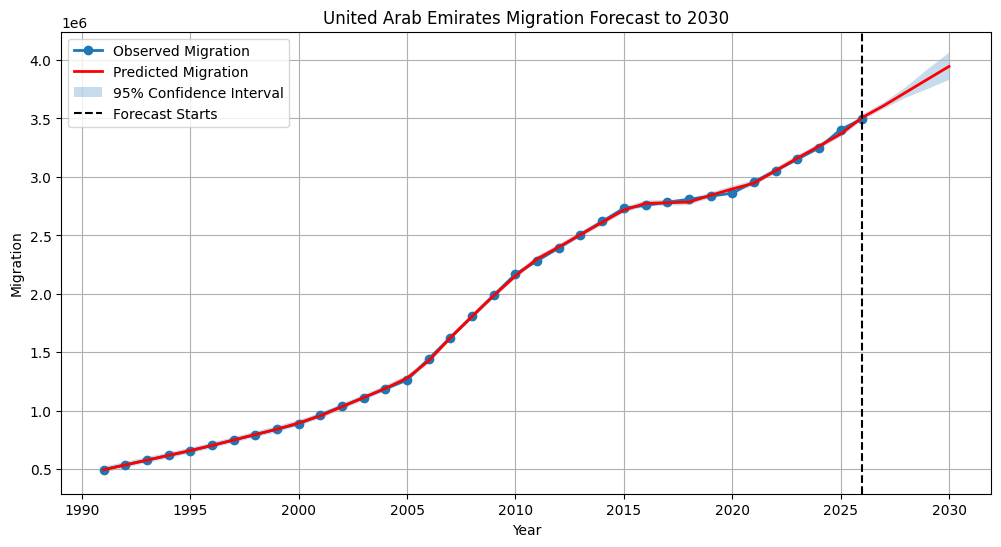

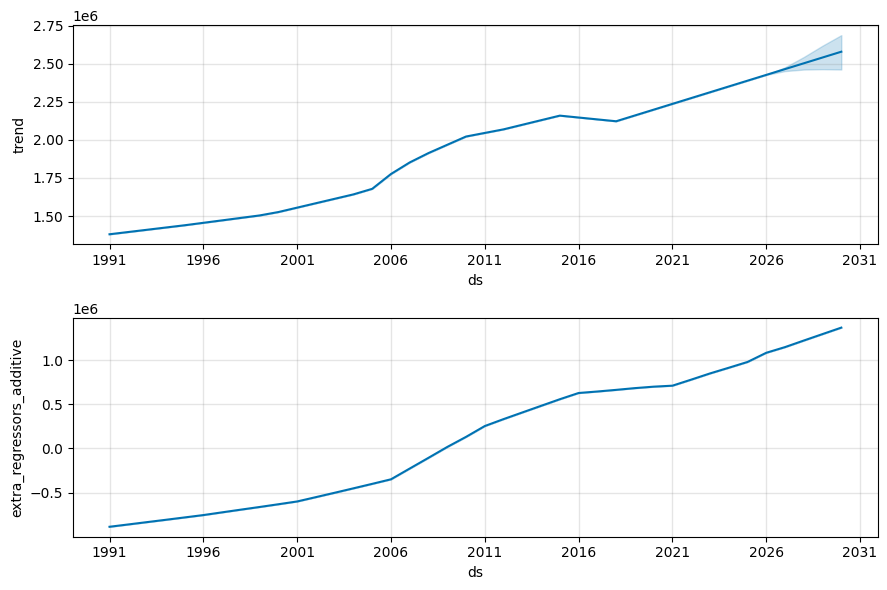


========== MODEL PERFORMANCE ==========

Country : United Arab Emirates
Mean Migration : 1,871,000.33
RMSE : 12,769.59
MAE  : 8,510.42
RMSE Percentage : 0.68%
MAE Percentage  : 0.45%
MAPE : 0.41%
Forecast Accuracy : 99.59%


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

# =====================================================
# LOAD DATA
# =====================================================

df = pd.read_excel("/content/Final_Master_Dataset_Cleaned (3).xlsx")

# =====================================================
# SELECT COUNTRY
# =====================================================

# country = "United Arab Emirates"
#country = "Qatar"
country = "United Arab Emirates"

df = df[df["Country"] == country].copy()
df = df.sort_values("Year").reset_index(drop=True)

# =====================================================
# CREATE LAG VARIABLES
# =====================================================

df["GDP_Lag1"] = df["GDP"].shift(1)
df["Migration_Lag1"] = df["Migration"].shift(1)

df = df.dropna().reset_index(drop=True)

# =====================================================
# PREPARE DATA
# =====================================================

prophet_df = df[
    ["Year","Migration","GDP_Lag1","Migration_Lag1"]
].copy()

prophet_df.columns = [
    "ds",
    "y",
    "GDP_Lag1",
    "Migration_Lag1"
]

prophet_df["ds"] = pd.to_datetime(
    prophet_df["ds"].astype(str) + "-01-01"
)

# =====================================================
# BUILD MODEL
# =====================================================

model = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.2,
    interval_width=0.95
)

model.add_regressor("GDP_Lag1")
model.add_regressor("Migration_Lag1")

model.fit(prophet_df)

# =====================================================
# CREATE FUTURE DATA
# =====================================================

future = model.make_future_dataframe(
    periods=4,
    freq="YS"
)

future["GDP_Lag1"] = np.nan
future["Migration_Lag1"] = np.nan

# Historical values
future.loc[:len(prophet_df)-1,"GDP_Lag1"] = prophet_df["GDP_Lag1"].values
future.loc[:len(prophet_df)-1,"Migration_Lag1"] = prophet_df["Migration_Lag1"].values

# Last available values
last_gdp = df["GDP"].iloc[-1]
last_migration = df["Migration"].iloc[-1]

# =====================================================
# RECURSIVE FORECAST
# =====================================================

for i in range(len(prophet_df), len(future)):

    future.loc[i,"GDP_Lag1"] = last_gdp
    future.loc[i,"Migration_Lag1"] = last_migration

    temp = future.iloc[[i]]

    pred = model.predict(temp)

    last_migration = pred["yhat"].values[0]

# =====================================================
# FINAL FORECAST
# =====================================================

forecast = model.predict(future)

# =====================================================
# FORECAST TABLE
# =====================================================

forecast_table = forecast[
    ["ds","yhat","yhat_lower","yhat_upper"]
].copy()

forecast_table["Year"] = forecast_table["ds"].dt.year

forecast_table = forecast_table[
    forecast_table["Year"] >= 2027
]

forecast_table = forecast_table[
    ["Year","yhat","yhat_lower","yhat_upper"]
]

forecast_table.columns = [
    "Year",
    "Predicted_Migration",
    "Lower_Bound",
    "Upper_Bound"
]

print("\n========== Forecast (2027-2030) ==========\n")
print(forecast_table)

# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(12,6))

plt.plot(
    df["Year"],
    df["Migration"],
    marker="o",
    linewidth=2,
    label="Observed Migration"
)

plt.plot(
    forecast["ds"].dt.year,
    forecast["yhat"],
    color="red",
    linewidth=2,
    label="Predicted Migration"
)

plt.fill_between(
    forecast["ds"].dt.year,
    forecast["yhat_lower"],
    forecast["yhat_upper"],
    alpha=0.25,
    label="95% Confidence Interval"
)

plt.axvline(
    x=df["Year"].max(),
    linestyle="--",
    color="black",
    label="Forecast Starts"
)

plt.title(country + " Migration Forecast to 2030")
plt.xlabel("Year")
plt.ylabel("Migration")
plt.grid(True)
plt.legend()
plt.show()

# =====================================================
# COMPONENTS
# =====================================================

fig2 = model.plot_components(forecast)
plt.show()

# =====================================================
# MODEL EVALUATION
# =====================================================

prediction = forecast.iloc[:len(prophet_df)]

actual = prophet_df["y"].values
predicted = prediction["yhat"].values

rmse = np.sqrt(mean_squared_error(actual, predicted))
mae = mean_absolute_error(actual, predicted)

mean_migration = actual.mean()

rmse_percent = (rmse / mean_migration) * 100
mae_percent = (mae / mean_migration) * 100

mask = actual != 0

mape = np.mean(
    np.abs((actual[mask]-predicted[mask])/actual[mask])
) * 100

accuracy = 100 - mape

# =====================================================
# RESULTS
# =====================================================

print("\n========== MODEL PERFORMANCE ==========\n")

print(f"Country : {country}")

print(f"Mean Migration : {mean_migration:,.2f}")

print(f"RMSE : {rmse:,.2f}")
print(f"MAE  : {mae:,.2f}")

print(f"RMSE Percentage : {rmse_percent:.2f}%")
print(f"MAE Percentage  : {mae_percent:.2f}%")

print(f"MAPE : {mape:.2f}%")
print(f"Forecast Accuracy : {accuracy:.2f}%")


COUNTRY : Oman

Forecast (2027-2030)

    Year  Predicted_Migration    Lower_Bound    Upper_Bound
36  2027        681437.280731  644855.887033  721560.909249
37  2028        674265.189561  635260.364184  713205.885803
38  2029        664305.662411  623200.828376  704222.676220
39  2030        652214.984812  611639.958135  689971.402775


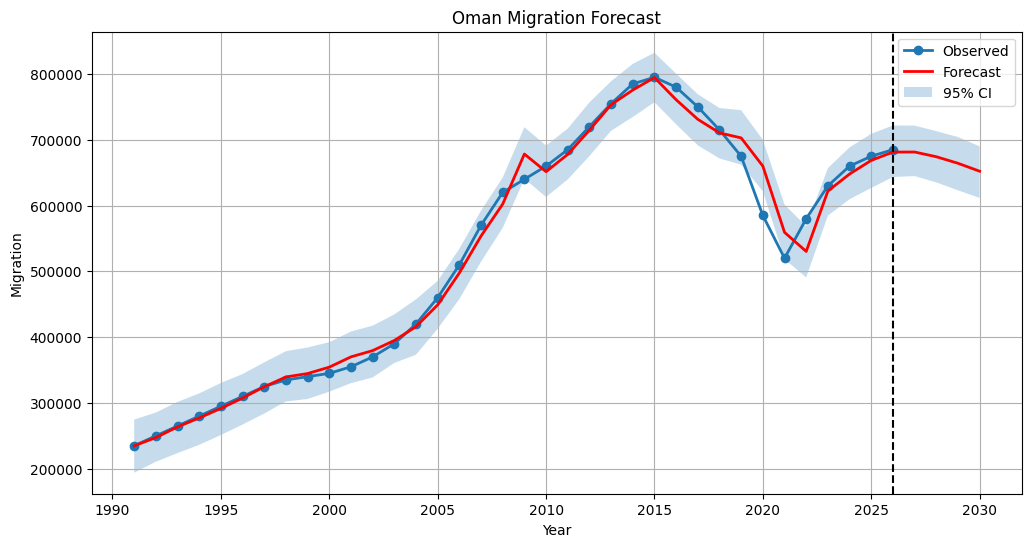

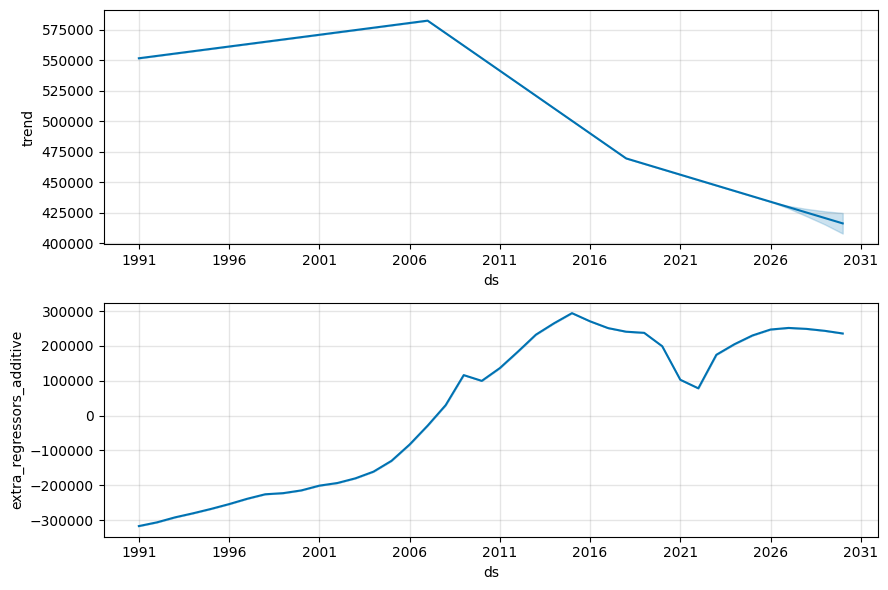


========== MODEL PERFORMANCE ==========

Country : Oman
Mean Migration : 526,944.44
RMSE : 20,074.82
MAE : 12,710.83
RMSE Percentage : 3.81%
MAE Percentage : 2.41%
MAPE : 2.32%
Forecast Accuracy : 97.68%

COUNTRY : Kuwait

Forecast (2027-2030)

    Year  Predicted_Migration   Lower_Bound   Upper_Bound
36  2027         1.044125e+06  1.023136e+06  1.062717e+06
37  2028         1.052742e+06  1.023551e+06  1.082169e+06
38  2029         1.060927e+06  1.014482e+06  1.103729e+06
39  2030         1.069110e+06  1.000399e+06  1.130389e+06


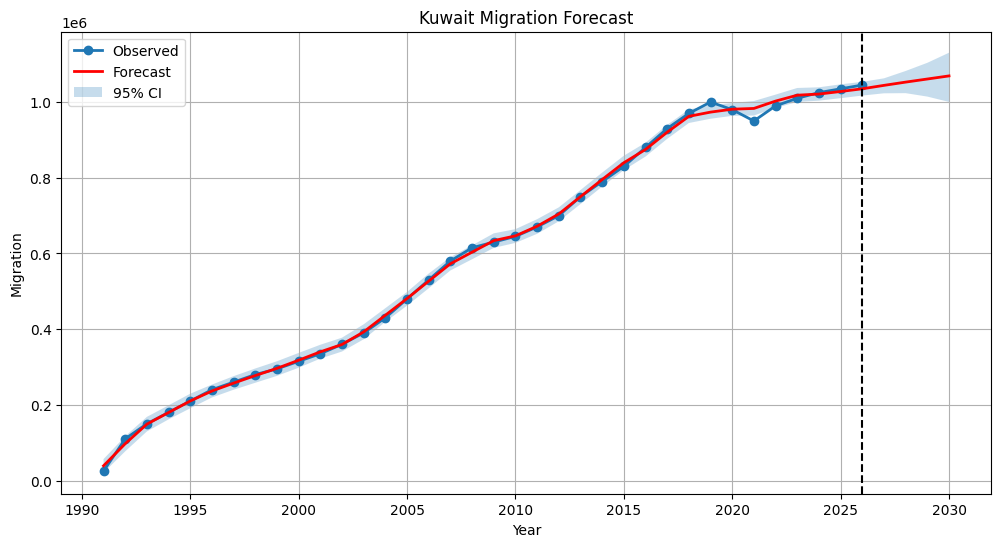

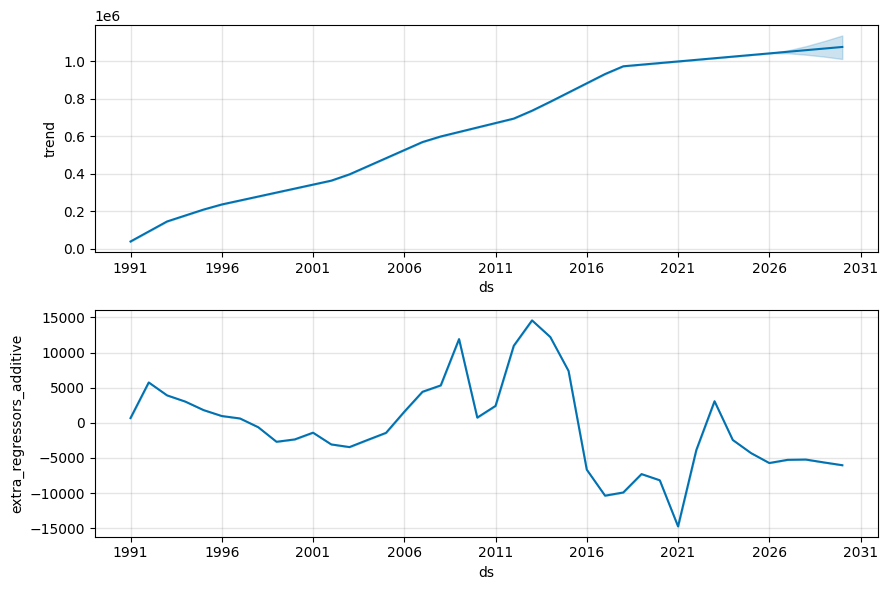


========== MODEL PERFORMANCE ==========

Country : Kuwait
Mean Migration : 600,416.67
RMSE : 9,430.79
MAE : 6,398.83
RMSE Percentage : 1.57%
MAE Percentage : 1.07%
MAPE : 2.70%
Forecast Accuracy : 97.30%

COUNTRY : Bahrain

Forecast (2027-2030)

    Year  Predicted_Migration    Lower_Bound    Upper_Bound
36  2027        354880.786627  337157.661066  371418.781567
37  2028        349114.547890  333493.704041  366082.757213
38  2029        342871.914299  326829.440382  360230.683431
39  2030        336288.228774  318766.597718  353007.385920


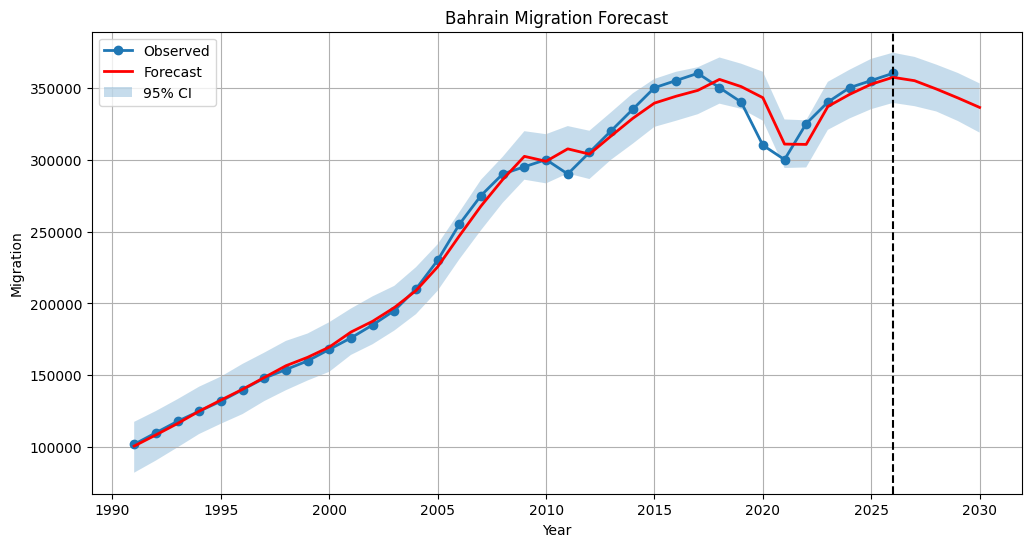

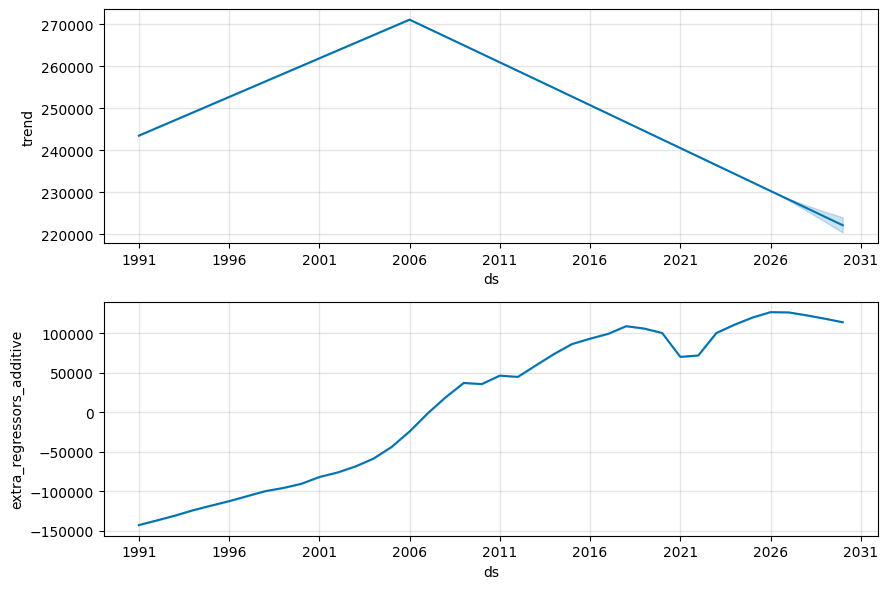


========== MODEL PERFORMANCE ==========

Country : Bahrain
Mean Migration : 253,138.89
RMSE : 8,504.32
MAE : 5,675.82
RMSE Percentage : 3.36%
MAE Percentage : 2.24%
MAPE : 2.01%
Forecast Accuracy : 97.99%


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

# =====================================================
# LOAD DATA
# =====================================================

df = pd.read_excel("/content/finaldatset_with_policy.xlsx")

# =====================================================
# COUNTRIES
# =====================================================

countries = [
    "Oman",
    "Kuwait",
    "Bahrain"
]

# =====================================================
# LOOP
# =====================================================

for country in countries:

    print("\n" + "="*70)
    print(f"COUNTRY : {country}")
    print("="*70)

    data = df[df["Country"] == country].copy()
    data = data.sort_values("Year").reset_index(drop=True)

    # -----------------------------
    # Lag Variables
    # -----------------------------

    data["GDP_Lag1"] = data["GDP"].shift(1)
    data["Migration_Lag1"] = data["Migration"].shift(1)

    data = data.dropna().reset_index(drop=True)

    # -----------------------------
    # Prophet Dataset
    # -----------------------------

    prophet_df = data[
        ["Year","Migration","GDP_Lag1","Migration_Lag1"]
    ].copy()

    prophet_df.columns = [
        "ds",
        "y",
        "GDP_Lag1",
        "Migration_Lag1"
    ]

    prophet_df["ds"] = pd.to_datetime(
        prophet_df["ds"].astype(str) + "-01-01"
    )

    # -----------------------------
    # Prophet Model
    # -----------------------------

    model = Prophet(
        yearly_seasonality=False,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=0.2,
        interval_width=0.95
    )

    model.add_regressor("GDP_Lag1")
    model.add_regressor("Migration_Lag1")

    model.fit(prophet_df)

    # -----------------------------
    # Future Data
    # -----------------------------

    future = model.make_future_dataframe(
        periods=4,
        freq="YS"
    )

    future["GDP_Lag1"] = np.nan
    future["Migration_Lag1"] = np.nan

    future.loc[:len(prophet_df)-1,"GDP_Lag1"] = prophet_df["GDP_Lag1"].values
    future.loc[:len(prophet_df)-1,"Migration_Lag1"] = prophet_df["Migration_Lag1"].values

    last_gdp = data["GDP"].iloc[-1]
    last_migration = data["Migration"].iloc[-1]

    # Recursive Forecast

    for i in range(len(prophet_df), len(future)):

        future.loc[i,"GDP_Lag1"] = last_gdp
        future.loc[i,"Migration_Lag1"] = last_migration

        pred = model.predict(future.iloc[[i]])

        last_migration = pred["yhat"].values[0]

    # -----------------------------
    # Forecast
    # -----------------------------

    forecast = model.predict(future)

    forecast_table = forecast[
        ["ds","yhat","yhat_lower","yhat_upper"]
    ].copy()

    forecast_table["Year"] = forecast_table["ds"].dt.year

    forecast_table = forecast_table[
        forecast_table["Year"] >= 2027
    ]

    forecast_table = forecast_table[
        ["Year","yhat","yhat_lower","yhat_upper"]
    ]

    forecast_table.columns = [
        "Year",
        "Predicted_Migration",
        "Lower_Bound",
        "Upper_Bound"
    ]

    print("\nForecast (2027-2030)\n")
    print(forecast_table)

    # Save Forecast

    forecast_table.to_excel(
        f"{country}_Prophet_Forecast_2030.xlsx",
        index=False
    )

    # -----------------------------
    # Plot
    # -----------------------------

    plt.figure(figsize=(12,6))

    plt.plot(
        data["Year"],
        data["Migration"],
        marker="o",
        linewidth=2,
        label="Observed"
    )

    plt.plot(
        forecast["ds"].dt.year,
        forecast["yhat"],
        color="red",
        linewidth=2,
        label="Forecast"
    )

    plt.fill_between(
        forecast["ds"].dt.year,
        forecast["yhat_lower"],
        forecast["yhat_upper"],
        alpha=0.25,
        label="95% CI"
    )

    plt.axvline(
        x=data["Year"].max(),
        linestyle="--",
        color="black"
    )

    plt.title(country + " Migration Forecast")
    plt.xlabel("Year")
    plt.ylabel("Migration")
    plt.grid(True)
    plt.legend()
    plt.show()

    # -----------------------------
    # Components
    # -----------------------------

    model.plot_components(forecast)
    plt.show()

    # -----------------------------
    # Evaluation
    # -----------------------------

    prediction = forecast.iloc[:len(prophet_df)]

    actual = prophet_df["y"].values
    predicted = prediction["yhat"].values

    rmse = np.sqrt(mean_squared_error(actual,predicted))
    mae = mean_absolute_error(actual,predicted)

    mean_migration = actual.mean()

    rmse_percent = (rmse/mean_migration)*100
    mae_percent = (mae/mean_migration)*100

    mask = actual != 0

    mape = np.mean(
        np.abs((actual[mask]-predicted[mask])/actual[mask])
    )*100

    accuracy = 100-mape

    print("\n========== MODEL PERFORMANCE ==========\n")

    print("Country :",country)
    print(f"Mean Migration : {mean_migration:,.2f}")
    print(f"RMSE : {rmse:,.2f}")
    print(f"MAE : {mae:,.2f}")
    print(f"RMSE Percentage : {rmse_percent:.2f}%")
    print(f"MAE Percentage : {mae_percent:.2f}%")
    print(f"MAPE : {mape:.2f}%")
    print(f"Forecast Accuracy : {accuracy:.2f}%")